# Chapter 9: Solving Nonlinear Equations

Companion notebook for *Python by Curiosity*. Every code listing from the chapter is
here, in the order it appears in the book, under the same title. Run the cells from
top to bottom: some listings use variables or functions defined in earlier cells.

The same listings are also available as separate scripts in `codes/listings/ch09_equations/`.

In [ ]:
# Run the listings from the repository root so that paths such as
# data/grades.csv and figures/trophy.png work.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working folder:", os.getcwd())

### Code 9.1: Bisection from scratch

In [2]:
import numpy as np

def bisect(f, a, b, tol=1e-10, max_iter=100):
    """Find root of f in [a,b] by bisection."""
    if f(a) * f(b) > 0:
        raise ValueError('f(a) and f(b) must have opposite signs')
    errors = []
    for i in range(max_iter):
        m = (a + b) / 2.0
        errors.append(abs(b - a) / 2)
        if abs(f(m)) < tol or (b - a) / 2 < tol:
            return m, errors
        if f(a) * f(m) < 0:
            b = m
        else:
            a = m
    return (a + b) / 2, errors

# Example: find root of x^3 - x - 2 = 0
f = lambda x: x**3 - x - 2      # a one-line function (Section 6.6)
root, errors = bisect(f, 1, 2)
print(f'Root found: {root:.10f}')
print(f'Iterations: {len(errors)}')
print(f'Final error bound: {errors[-1]:.2e}')

Root found: 1.5213797068
Iterations: 33
Final error bound: 1.16e-10


### Code 9.2: Newton-Raphson from scratch

In [3]:
import numpy as np

def newton(f, df, x0, tol=1e-10, max_iter=50):
    """Newton-Raphson root finder."""
    x = float(x0)
    errors = []
    for i in range(max_iter):
        fx = f(x)
        errors.append(abs(fx))
        if abs(fx) < tol:
            return x, errors
        dfx = df(x)
        if dfx == 0:
            raise ZeroDivisionError('Derivative is zero')
        x = x - fx / dfx
    return x, errors

f  = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1
root_nr, errors_nr = newton(f, df, x0=1.5)
print(f'Newton root: {root_nr:.10f}')
print(f'Iterations:  {len(errors_nr)}')

Newton root: 1.5213797068
Iterations:  4


### Code 9.3: Bisection vs Newton-Raphson convergence

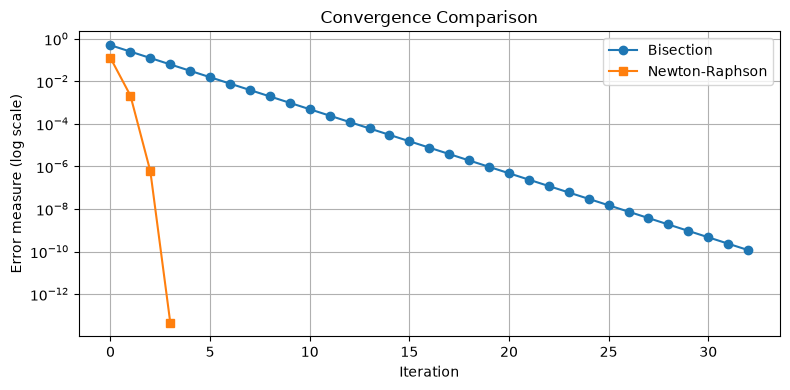

In [4]:
# Uses bisect() and newton() from Codes 9.1 and 9.2: run those first
import numpy as np
import matplotlib.pyplot as plt

f = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1

root, errors = bisect(f, 1, 2)
root_nr, errors_nr = newton(f, df, x0=1.5)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(errors,    marker='o', label='Bisection')
ax.semilogy(errors_nr, marker='s', label='Newton-Raphson')
ax.set_xlabel('Iteration'); ax.set_ylabel('Error measure (log scale)')
ax.set_title('Convergence Comparison'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('fig09-01-convergence.pdf')

### Code 9.4: scipy equivalents

In [5]:
import numpy as np
from scipy.optimize import brentq, newton as sp_newton

f  = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1

# brentq: robust bracketing method (like bisection but faster)
root_bq = brentq(f, 1, 2, xtol=1e-10)

# newton: Newton-Raphson (or secant if fprime not given)
root_sp = sp_newton(f, x0=1.5, fprime=df, tol=1e-10)

print(f"Brentq root: {root_bq:.10f}")
print(f"SciPy Newton root: {root_sp:.10f}")

Brentq root: 1.5213797068
SciPy Newton root: 1.5213797068


### Code 9.5: System solved with fsolve

In [6]:
import numpy as np
from scipy.optimize import fsolve

def system(vars):
    x, y = vars
    return [x**2 + y**2 - 4,   # circle of radius 2
            x - y - 1]          # line

sol = fsolve(system, x0=[1, 0])
print(f'x = {sol[0]:.6f}, y = {sol[1]:.6f}')
# Verify: plug back in
print('Residual:', system(sol))

x = 1.822876, y = 0.822876
Residual: [np.float64(-8.881784197001252e-16), np.float64(0.0)]


### Worked Example 9.1: Bisection Method Step-by-Step Implementation

In [7]:
import numpy as np

def bisection(f, a, b, tol=1e-6, max_iter=50):
    if f(a) * f(b) >= 0:
        raise ValueError("Function must have opposite signs at bracket endpoints.")
    
    print(f"{'k':<3} | {'a':<9} | {'b':<9} | {'c (Midpoint)':<12} | {'f(c)':<11} | {'Error':<9}")
    print("-" * 62)
    
    for k in range(1, max_iter + 1):
        c = (a + b) / 2.0
        fc = f(c)
        err = (b - a) / 2.0
        
        if k <= 5 or err < tol:  # Print first 5 steps and final step
            print(f"{k:<3} | {a:<9.6f} | {b:<9.6f} | {c:<12.6f} | {fc:<11.4e} | {err:<9.2e}")
            
        if abs(fc) < 1e-12 or err < tol:
            return c, k
            
        if f(a) * fc < 0:
            b = c
        else:
            a = c
            
    return (a + b) / 2.0, max_iter

# Target function f(x) = x^3 - 4x - 9
f = lambda x: x**3 - 4*x - 9
root, iterations = bisection(f, 2.0, 3.0, tol=1e-6)
print(f"\nFinal Root: x = {root:.6f} found in {iterations} iterations.")

# Output:
# k   | a         | b         | c (Midpoint) | f(c)        | Error    
# --------------------------------------------------------------
# 1   | 2.000000  | 3.000000  | 2.500000     | -3.3750e+00 | 5.00e-01
# 2   | 2.500000  | 3.000000  | 2.750000     | 7.9688e-01  | 2.50e-01
# 3   | 2.500000  | 2.750000  | 2.625000     | -1.4121e+00 | 1.25e-01
# 4   | 2.625000  | 2.750000  | 2.687500     | -3.3911e-01 | 6.25e-02
# 5   | 2.687500  | 2.750000  | 2.718750     | 2.2092e-01  | 3.12e-02
# 20  | 2.706528  | 2.706530  | 2.706529     | 1.2747e-05  | 9.54e-07
# 
# Final Root: x = 2.706529 found in 20 iterations.

k   | a         | b         | c (Midpoint) | f(c)        | Error    
--------------------------------------------------------------
1   | 2.000000  | 3.000000  | 2.500000     | -3.3750e+00 | 5.00e-01 
2   | 2.500000  | 3.000000  | 2.750000     | 7.9688e-01  | 2.50e-01 
3   | 2.500000  | 2.750000  | 2.625000     | -1.4121e+00 | 1.25e-01 
4   | 2.625000  | 2.750000  | 2.687500     | -3.3911e-01 | 6.25e-02 
5   | 2.687500  | 2.750000  | 2.718750     | 2.2092e-01  | 3.12e-02 
20  | 2.706528  | 2.706530  | 2.706529     | 1.2747e-05  | 9.54e-07 

Final Root: x = 2.706529 found in 20 iterations.


### Worked Example 9.2: Newton-Raphson Method & Quadratic Convergence

In [8]:
import numpy as np

def newton_raphson(f, df, x0, tol=1e-10, max_iter=20):
    x = float(x0)
    print(f"{'k':<3} | {'x_k':<12} | {'f(x_k)':<12} | {'Correction dx':<12}")
    print("-" * 46)
    
    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)
        dx = fx / dfx
        
        print(f"{k:<3} | {x:<12.8f} | {fx:<12.4e} | {dx:<12.4e}")
        
        if abs(fx) < tol:
            return x, k            # k updates were needed
            
        x -= dx
        
    return x, max_iter

# f(x) = cos(x) - x, f'(x) = -sin(x) - 1
f = lambda x: np.cos(x) - x
df = lambda x: -np.sin(x) - 1.0

root, steps = newton_raphson(f, df, x0=0.5)
print(f"\nNewton-Raphson Root: x = {root:.10f} in {steps} iterations.")

# Output:
# k   | x_k          | f(x_k)       | Correction dx
# ----------------------------------------------
# 0   | 0.50000000   | 3.7758e-01   | -2.5522e-01
# 1   | 0.75522242   | -2.7103e-02  | 1.6081e-02
# 2   | 0.73914167   | -9.4615e-05  | 5.6532e-05
# 3   | 0.73908513   | -1.1810e-09  | 7.0565e-10
# 4   | 0.73908513   | 0.0000e+00   | -0.0000e+00
# 
# Newton-Raphson Root: x = 0.7390851332 in 4 iterations.

k   | x_k          | f(x_k)       | Correction dx
----------------------------------------------
0   | 0.50000000   | 3.7758e-01   | -2.5522e-01 
1   | 0.75522242   | -2.7103e-02  | 1.6081e-02  
2   | 0.73914167   | -9.4615e-05  | 5.6532e-05  
3   | 0.73908513   | -1.1810e-09  | 7.0565e-10  
4   | 0.73908513   | 0.0000e+00   | -0.0000e+00 

Newton-Raphson Root: x = 0.7390851332 in 4 iterations.


### Worked Example 9.3: Sports Biomechanics - Olympic Shot Put Release Angle Solver

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Physical constants for Olympic shot put
h0 = 2.0         # Release height above ground (m)
v0 = 13.5        # Initial release speed (m/s)
g  = 9.81        # Gravitational acceleration (m/s^2)
d_target = 20.0  # Target distance mark (m)

# Trajectory height y(x; theta) in degrees
def trajectory(x, theta_deg):
    rad = np.radians(theta_deg)
    return h0 + x * np.tan(rad) - (g * x**2) / (2 * v0**2 * (np.cos(rad)**2))

# Residual function: f(theta) = landing height at target distance d_target
f_shot = lambda theta_deg: trajectory(d_target, theta_deg)

# Solve for required release angle theta using Brent's method
theta_opt = brentq(f_shot, 30.0, 40.0)

# Calculate landing distance of a standard 45-degree throw
landing_45 = brentq(lambda x: trajectory(x, 45.0), 15.0, 25.0)

print(f"Optimal Release Angle:  {theta_opt:.2f} deg (Lands exact at {d_target:.1f}m)")
print(f"Standard 45 deg Throw:  Lands at {landing_45:.2f}m")

# Output:
# Optimal Release Angle:  35.31 deg (Lands exact at 20.0m)
# Standard 45 deg Throw:  Lands at 20.40m

Optimal Release Angle:  35.31 deg (Lands exact at 20.0m)
Standard 45 deg Throw:  Lands at 20.40m


### Worked Example 9.4: Multivariable Non-linear System of Equations

In [10]:
import numpy as np
import scipy.optimize as opt

# Non-linear 2D system vector function
def system(vec):
    x, y = vec
    f1 = x**2 + y**2 - 4.0   # Circle constraint
    f2 = x * y - 1.0         # Hyperbola constraint
    return [f1, f2]

# Initial guess in first quadrant
x0 = [1.5, 0.5]

# Solve system using SciPy's 'hybr' (Powell hybrid) solver
sol = opt.root(system, x0, method='hybr')

x_sol, y_sol = sol.x
residuals = sol.fun

print(f"Intersection Point: x = {x_sol:.6f}, y = {y_sol:.6f}")
print(f"Residual Vector:   [{residuals[0]:.2e}, {residuals[1]:.2e}]")
print(f"Solver Success:    {sol.success}")

# Output:
# Intersection Point: x = 1.931852, y = 0.517638
# Residual Vector:   [1.33e-13, 6.86e-13]   (tiny; exact digits vary)
# Solver Success:    True

Intersection Point: x = 1.931852, y = 0.517638
Residual Vector:   [1.33e-13, 6.86e-13]
Solver Success:    True
